Olá, Micaela

Meu nome é Ramon. Ao ao longo do texto farei algumas observações sobre melhorias no código. Nas partes em que não houver comentários, está tudo certo, ok? Estarei aberto a feedbacks e discussões sobre o tema.

**Peço que mantenha e não altere os comentários que eu fizer por aqui para que possamos nos localizar posteriormente, ok?**

Mais uma coisa, vamos utilizar um código de cores para você entender os meus feedbacks no seu notebook. Funciona assim:

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

Sucesso. Tudo foi feito corretamente.
</div>

<div class="alert alert-block alert-warning">
<b>Comentário do revisor: </b> <a class="tocSkip"></a>

Alerta não crítco, mas que pode ser corrigido para melhoria geral no seu código/análise
</div>

<div class="alert alert-block alert-danger">

<b>Comentário do revisor: </b> <a class="tocSkip"></a>
    
Erro que precisa ser consertado, caso contrário seu projeto **não** será aceito.
</div>

Você pode me responder usando isso:
<div class="alert alert-block alert-info">
<b>Resposta do Aluno.</b> <a class="tocSkip"></a>
</div>

###

<div class="alert alert-block alert-success">
<b>Comentário Geral do Revisor</b> <a class="tocSkip"></a>

Obrigado por enviar seu projeto. 
    
Parabéns, você fez um bom trabalho.

Como pontos fortes do projeto, destaco:
- Código simples e eficiente (sem loop desnecessário)
- Uso adequado dos recursos da lição
    
<span class="text-danger">Porém, há espaço para melhorias: </span>
 * <span class="text-danger">ajustar análise de receita, ajustar teste de hipótese </span>


Portanto, sugiro que você corrija os pontos indicados.
    
Se você tiver alguma dúvida sobre de algo que você não tenha entendido, sinta-se à vontade para perguntar ao tutor ou deixar um comentário em **azul** para que, na próxima iteração, eu possa responder.

Conte conosco. Lembre-se de que você pode tirar dúvidas com revisores usando os comentários ou buscar ajuda de um tutor.
Bom trabalho. 


</div>


<div class="alert alert-block alert-success">
<b> Comentário Geral do revisor: </b> <a class="tocSkip"></a>

Tudo certo agora. Parabéns pelo empenho. Desejo sucesso na jornada.

</div>

# Qual é o melhor plano?

Você trabalha como analista para a empresa de telecomunicações Megaline. A empresa oferece aos clientes dois planos pré-pagos: Surf e Ultimate. O departamento comercial quer saber qual dos planos gera mais receita para ajustar o orçamento de publicidade.

Você vai realizar uma análise preliminar dos planos com base em uma pequena seleção de clientes. Você terá dados de 500 clientes da Megaline: que clientes são, de onde eles são, qual plano usam e o número de chamadas e mensagens realizadas em 2018. Seu trabalho é analisar o comportamento dos clientes e determinar qual plano pré-pago gera mais receita.

[Fornecemos alguns comentários para guiar sua linha de raciocínio enquanto você trabalha neste projeto. Entretanto, certifique-se de remover todos os comentários entre colchetes antes de enviar o projeto.]

[Antes de começar a análise dos dados, explique com suas próprias palavras o propósito do projeto e as ações que planeja realizar.]

[Tenha em mente que estudar, modificar e analisar dados é um processo iterativo. É normal retornar a etapas anteriores e corrigir/expandir algo para permitir as próximas etapas.]

Objetivo
Analisar o comportamento de 500 clientes da Megaline em 2018 e determinar qual plano pré-pago (Surf ou Ultimate) gera maior receita média mensal, verificando se a diferença é estatisticamente significativa.

O que vou fazer:

Carregar e inspecionar os dados (users, calls, messages, internet, plans).
Limpar e padronizar tipos; criar colunas de mês/ano.
Calcular métricas mensais por cliente: chamadas, minutos, SMS, dados.
Aplicar as regras de arredondamento (chamadas → por chamada para cima em minutos; internet → somar MB no mês e arredondar GB para cima).
Calcular receita mensal por cliente conforme o plano.
Descrever distribuições (média, variância, desvio-padrão) e visualizar histogramas.

Testar hipóteses:
  H0: receita média dos planos Surf e Ultimate é igual.
  H1: é diferente.
  H2: receita média NY-NJ = outras regiões.
  H3: é diferente.

Concluir qual plano é mais rentável e com que confiança.

## Inicialização

In [1]:
# Carregando todas as bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')



## Carregue os dados

In [2]:
# Carregue os arquivos de dados em diferentes DataFrames

# Leitura com parsing de datas
users = pd.read_csv('/datasets/megaline_users.csv', parse_dates=['reg_date', 'churn_date'])
calls = pd.read_csv('/datasets/megaline_calls.csv', parse_dates=['call_date'])
messages = pd.read_csv('/datasets/megaline_messages.csv', parse_dates=['message_date'])
internet = pd.read_csv('/datasets/megaline_internet.csv', parse_dates=['session_date'])
plans = pd.read_csv('/datasets/megaline_plans.csv')

# Checagem rápida
for name, df in [('users', users), ('calls', calls), ('messages', messages), ('internet', internet), ('plans', plans)]:
    print(f'== {name} ==')
    display(df.head(3))
    df.info()
    print()


== users ==


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaT
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaT


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     datetime64[ns]
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 31.4+ KB

== calls ==


,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 4.2+ MB

== messages ==


...

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.7+ MB

== internet ==


,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 3.2+ MB

== plans ==


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes



## Prepare os dados

Após carregar os datasets, confirmei que todas as tabelas contêm os tipos de dados esperados.

As colunas de datas (reg_date, churn_date, call_date, message_date, session_date) foram convertidas para o formato datetime.
As tabelas não apresentam valores nulos relevantes além da coluna churn_date, onde os valores ausentes indicam que o utilizador ainda estava ativo em 2018.
As durações das chamadas (duration) estão em minutos com casas decimais, e as quantidades de dados (mb_used) em megabytes.
Não há duplicados aparentes e os identificadores (user_id, id) estão únicos.

Na próxima etapa, tenho de:

Criar colunas de ano e mês para agrupar dados mensais;
Arredondar cada duração de chamada para cima (em minutos);
Somar o uso de internet mensal e arredondar o total de MB para GB;
Juntar todas as métricas (chamadas, mensagens, internet) por cliente e mês para cálculo de receita.

## Planos

In [3]:
# Imprima informações gerais/resumo sobre o DataFrame dos planos

plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [4]:
# Imprima uma amostra de dados dos planos
display(plans)

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


A tabela plans contém dois planos pré-pagos — Surf e Ultimate.
Cada linha representa um plano com os respetivos limites mensais e preços.

Observações gerais:

As colunas mostram claramente o número de minutos, mensagens e megabytes incluídos em cada plano, além dos custos adicionais por excedente.
Todos os tipos de dados estão corretos (int64 para valores numéricos inteiros e float64 para valores decimais como preços por minuto e por GB).
Não há valores ausentes nem duplicados.
As unidades estão consistentes: o tráfego de internet é medido em megabytes (1 GB = 1024 MB).
Não há erros de formatação nem inconsistências de capitalização.

Conclusão:
A tabela está limpa e pronta para ser usada na etapa de cálculo de receita. Nenhuma correção é necessária aqui.

## Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [5]:
# Verificar se há chamadas com duração zero
zero_calls = calls[calls['duration'] == 0]
print(f"Chamadas com duração 0: {len(zero_calls)}")

# Remover essas chamadas, pois o enunciado indica que até 1 segundo conta como 1 minuto
calls = calls[calls['duration'] > 0]

# Verificar se há sessões de internet com 0 MB (pode ocorrer quando não houve tráfego real)
zero_internet = internet[internet['mb_used'] == 0]
print(f"Sessões de internet com 0 MB: {len(zero_internet)}")

# Mantemos essas linhas, pois representam sessões em que o utilizador se conectou mas não consumiu dados
# (não há erro a corrigir aqui)

Chamadas com duração 0: 26834
Sessões de internet com 0 MB: 13747


Foram verificadas possíveis inconsistências nas tabelas de chamadas e internet.

A tabela calls apresentava algumas chamadas com duração igual a 0. Essas linhas foram removidas, pois segundo o enunciado qualquer chamada, mesmo de um segundo, é arredondada para 1 minuto.
A tabela internet tinha sessões com 0 MB usados. Essas linhas não foram removidas, pois representam ligações em que o utilizador não chegou a consumir dados, o que é plausível.
Não foram encontradas anomalias relevantes nas tabelas messages, users ou plans.

## 1.6 Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

In [6]:
# Adicionar colunas derivadas que podem ser úteis nas análises

# 1) Criar colunas de ano e mês para facilitar agrupamentos
for df, date_col in [(calls, 'call_date'), (messages, 'message_date'), (internet, 'session_date')]:
    df['year'] = df[date_col].dt.year
    df['month'] = df[date_col].dt.month

# 2) Arredondar duração das chamadas (seguindo regra do enunciado)
calls['minutes_ceil'] = np.ceil(calls['duration']).astype(int)

# 3) Converter MB para GB em internet (arredondado depois na agregação)
internet['gb_used'] = internet['mb_used'] / 1024

# 4) Verificar resultado
display(calls.head(3))
display(internet.head(3))

,id,user_id,call_date,duration,year,month,minutes_ceil
0,1000_93,1000,2018-12-27,8.52,2018,12,9
1,1000_145,1000,2018-12-27,13.66,2018,12,14
2,1000_247,1000,2018-12-27,14.48,2018,12,15


,id,user_id,session_date,mb_used,year,month,gb_used
0,1000_13,1000,2018-12-29,89.86,2018,12,0.09
1,1000_204,1000,2018-12-31,0.00,2018,12,0.00
2,1000_379,1000,2018-12-28,660.40,2018,12,0.64


Foram adicionadas colunas auxiliares para facilitar a análise mensal e o cálculo de receita:

year e month foram extraídas das datas nas tabelas calls, messages e internet.
As durações das chamadas foram arredondadas para cima, criando a coluna minutes_ceil.
A coluna gb_used converte o tráfego de internet de MB para GB, o que torna os cálculos mais claros e consistentes com o plano de cobrança.
Essas colunas adicionais simplificam as próximas etapas de agregação e comparação de planos.

## Usuários

In [7]:
# Imprima informações gerais/resumo sobre o DataFrame dos usuários
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     datetime64[ns]
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 31.4+ KB


In [8]:
# Imprima uma amostra de dados dos usuários
display(users.head(10))

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaT
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaT
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaT
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaT
5,1005,Livia,Shields,31,"Dallas-Fort Worth-Arlington, TX MSA",2018-11-29,surf,NaT
6,1006,Jesusa,Bradford,73,"San Francisco-Oakland-Berkeley, CA MSA",2018-11-27,ultimate,2018-12-18
7,1007,Eusebio,Welch,42,"Grand Rapids-Kentwood, MI MSA",2018-07-11,surf,NaT
8,1008,Emely,Hoffman,53,"Orlando-Kissimmee-Sanford, FL MSA",2018-08-03,ultimate,NaT
9,1009,Gerry,Little,19,"San Jose-Sunnyvale-Santa Clara, CA MSA",2018-04-22,surf,NaT


A tabela users apresenta 500 registos, cada um representando um cliente da Megaline.

O que observei:

Todos os tipos de dados estão adequados: datas (datetime64), texto (object) e números inteiros (int64).
A coluna churn_date contém valores ausentes em 466 casos, o que faz sentido, pois esses clientes ainda estavam ativos no momento da extração dos dados.
As idades variam de forma realista (sem valores extremos ou negativos).
As cidades estão formatadas de maneira consistente, incluindo a designação “MSA”.
Não há valores duplicados nem campos inválidos.

Conclusão:
A base de utilizadores está limpa, coerente e pronta para integração com os demais dados.
Nenhuma correção adicional é necessária além da verificação dos NaN esperados em churn_date.

### Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [9]:
# Verificar duplicados e valores ausentes
print("Duplicados:", users.duplicated().sum())
print("\nValores ausentes por coluna:")
print(users.isna().sum())

# Nenhuma correção necessária, mas se existissem duplicados, faríamos:
# users = users.drop_duplicates().reset_index(drop=True)

Duplicados: 0

Valores ausentes por coluna:
user_id         0
first_name      0
last_name       0
age             0
city            0
reg_date        0
plan            0
churn_date    466
dtype: int64


### Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

In [10]:
# Criar uma nova coluna opcional com o tempo de uso (em dias)
# Clientes ainda ativos terão o cálculo até o fim do ano de 2018
users['churn_date_filled'] = users['churn_date'].fillna(pd.Timestamp('2018-12-31'))
users['days_active'] = (users['churn_date_filled'] - users['reg_date']).dt.days

display(users[['user_id', 'reg_date', 'churn_date', 'days_active']].head())

,user_id,reg_date,churn_date,days_active
0,1000,2018-12-24,NaT,7
1,1001,2018-08-13,NaT,140
2,1002,2018-10-21,NaT,71
3,1003,2018-01-28,NaT,337
4,1004,2018-05-23,NaT,222


## Chamadas

In [11]:
# Imprima informações gerais/resumo sobre o DataFrame das chamadas
calls.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 110901 entries, 0 to 137734
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            110901 non-null  object        
 1   user_id       110901 non-null  int64         
 2   call_date     110901 non-null  datetime64[ns]
 3   duration      110901 non-null  float64       
 4   year          110901 non-null  int64         
 5   month         110901 non-null  int64         
 6   minutes_ceil  110901 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(4), object(1)
memory usage: 6.8+ MB


In [12]:
# Imprima uma amostra de dados das chamadas
display(calls.head(10))

,id,user_id,call_date,duration,year,month,minutes_ceil
0,1000_93,1000,2018-12-27,8.52,2018,12,9
1,1000_145,1000,2018-12-27,13.66,2018,12,14
2,1000_247,1000,2018-12-27,14.48,2018,12,15
3,1000_309,1000,2018-12-28,5.76,2018,12,6
4,1000_380,1000,2018-12-30,4.22,2018,12,5
5,1000_388,1000,2018-12-31,2.20,2018,12,3
6,1000_510,1000,2018-12-27,5.75,2018,12,6
7,1000_521,1000,2018-12-28,14.18,2018,12,15
8,1000_530,1000,2018-12-28,5.77,2018,12,6
9,1000_544,1000,2018-12-26,4.40,2018,12,5


A tabela calls contém 137.735 registros, representando as chamadas efetuadas pelos clientes da Megaline.

O que observei:

As colunas estão com tipos de dados apropriados:
id e user_id como identificadores;
call_date como data (datetime64);
duration como número decimal (float64).
Não há valores ausentes nem duplicados.

Foram encontradas algumas chamadas com duração igual a 0 minutos, o que é inconsistente, já que o enunciado afirma que todas as chamadas são arredondadas para 1 minuto, mesmo as muito curtas.
Fora isso, os dados parecem coerentes e não há necessidade de correção adicional.

Como corrigir:
As linhas com duration == 0 devem ser removidas, garantindo que todas as chamadas contabilizem pelo menos um minuto — essa limpeza será feita na próxima etapa (1.8.1 Corrija os dados).

### Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [13]:
# Verificar quantas chamadas têm duração igual a 0
zero_calls = calls[calls['duration'] == 0]
print(f"Número de chamadas com duração 0: {len(zero_calls)}")

# Remover as chamadas de duração zero, pois mesmo as curtas devem contar como 1 minuto
calls = calls[calls['duration'] > 0]

# Verificar novamente para garantir que foram removidas
print(f"Número de chamadas após remoção: {len(calls)}")

Número de chamadas com duração 0: 0
Número de chamadas após remoção: 110901


### Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

In [14]:
# Adicionar colunas de ano e mês para facilitar a agregação mensal
calls['year'] = calls['call_date'].dt.year
calls['month'] = calls['call_date'].dt.month

# Criar coluna de minutos arredondados para cima
calls['minutes_ceil'] = np.ceil(calls['duration']).astype(int)

# Verificar resultado
display(calls.head(10))

,id,user_id,call_date,duration,year,month,minutes_ceil
0,1000_93,1000,2018-12-27,8.52,2018,12,9
1,1000_145,1000,2018-12-27,13.66,2018,12,14
2,1000_247,1000,2018-12-27,14.48,2018,12,15
3,1000_309,1000,2018-12-28,5.76,2018,12,6
4,1000_380,1000,2018-12-30,4.22,2018,12,5
5,1000_388,1000,2018-12-31,2.20,2018,12,3
6,1000_510,1000,2018-12-27,5.75,2018,12,6
7,1000_521,1000,2018-12-28,14.18,2018,12,15
8,1000_530,1000,2018-12-28,5.77,2018,12,6
9,1000_544,1000,2018-12-26,4.40,2018,12,5


## Mensagens

In [15]:
# Imprima informações gerais/resumo sobre o DataFrame das mensagens
messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
 3   year          76051 non-null  int64         
 4   month         76051 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 2.9+ MB


In [16]:
# Imprima uma amostra dos dados das mensagens
display(messages.head(10))

,id,user_id,message_date,year,month
0,1000_125,1000,2018-12-27,2018,12
1,1000_160,1000,2018-12-31,2018,12
2,1000_223,1000,2018-12-31,2018,12
3,1000_251,1000,2018-12-27,2018,12
4,1000_255,1000,2018-12-26,2018,12
5,1000_346,1000,2018-12-29,2018,12
6,1000_386,1000,2018-12-30,2018,12
7,1000_413,1000,2018-12-31,2018,12
8,1000_502,1000,2018-12-27,2018,12
9,1000_525,1000,2018-12-28,2018,12


A tabela messages contém 76.051 registros, cada um representando uma mensagem de texto enviada por um utilizador.

O que observei:
As colunas id, user_id e message_date têm tipos de dados apropriados (object, int64 e datetime64).
Não há valores ausentes nem duplicados.
As datas estão concentradas no ano de 2018, conforme esperado.
Os dados parecem consistentes e não requerem correções adicionais.

Conclusão:
O dataset está limpo e pronto para ser agregado por mês e por utilizador.

### Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [17]:
# Verificar se há valores ausentes ou duplicados na tabela de mensagens
print("Valores ausentes por coluna:")
print(messages.isna().sum())

print("\nDuplicados:", messages.duplicated().sum())


Valores ausentes por coluna:
id              0
user_id         0
message_date    0
year            0
month           0
dtype: int64

Duplicados: 0


### Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

In [18]:
# Adicionar colunas de ano e mês para facilitar os agrupamentos mensais
messages['year'] = messages['message_date'].dt.year
messages['month'] = messages['message_date'].dt.month

# Conferir resultado
display(messages.head())

,id,user_id,message_date,year,month
0,1000_125,1000,2018-12-27,2018,12
1,1000_160,1000,2018-12-31,2018,12
2,1000_223,1000,2018-12-31,2018,12
3,1000_251,1000,2018-12-27,2018,12
4,1000_255,1000,2018-12-26,2018,12


## Internet

In [19]:
# Imprima informações gerais/resumo sobre o DataFrame da internet
internet.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
 4   year          104825 non-null  int64         
 5   month         104825 non-null  int64         
 6   gb_used       104825 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(1)
memory usage: 5.6+ MB


In [20]:
#  Imprima uma amostra de dados para o tráfego da internet
display(internet.head(10))

,id,user_id,session_date,mb_used,year,month,gb_used
0,1000_13,1000,2018-12-29,89.86,2018,12,0.09
1,1000_204,1000,2018-12-31,0.00,2018,12,0.00
2,1000_379,1000,2018-12-28,660.40,2018,12,0.64
3,1000_413,1000,2018-12-26,270.99,2018,12,0.26
4,1000_442,1000,2018-12-27,880.22,2018,12,0.86
5,1001_0,1001,2018-08-24,284.68,2018,8,0.28
6,1001_3,1001,2018-12-09,656.04,2018,12,0.64
7,1001_4,1001,2018-11-04,16.97,2018,11,0.02
8,1001_10,1001,2018-11-27,135.18,2018,11,0.13
9,1001_15,1001,2018-12-13,761.92,2018,12,0.74


[Descreva o que você nota sobre as informações gerais e sobre a amostra de dados impressa acima. Existem problemas (tipos de dados inadequados, dados ausentes, etc.) que precisam de mais investigação e alterações? Como isso pode ser corrigido?]

A tabela internet contém 104.825 registros, representando sessões de uso de dados dos clientes da Megaline.

O que observei:
As colunas id, user_id, session_date e mb_used estão com tipos de dados corretos (object, int64, datetime64 e float64).
Não há valores ausentes nem duplicados.
Existem sessões com mb_used == 0, o que pode indicar conexões em que o utilizador não chegou a consumir dados.
Esses casos são válidos e não precisam ser removidos, já que representam tentativas de conexão sem tráfego.

Conclusão:
Os dados estão limpos, mas serão enriquecidos com colunas de mês, ano e gigabytes para facilitar a análise.

### Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [21]:
# Verificar valores ausentes e duplicados
print("Valores ausentes por coluna:")
print(internet.isna().sum())

print("\nDuplicados:", internet.duplicated().sum())

# Verificar quantas sessões têm 0 MB usados
zero_sessions = internet[internet['mb_used'] == 0]
print(f"\nSessões com 0 MB usados: {len(zero_sessions)}")

Valores ausentes por coluna:
id              0
user_id         0
session_date    0
mb_used         0
year            0
month           0
gb_used         0
dtype: int64

Duplicados: 0

Sessões com 0 MB usados: 13747


### Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

In [22]:
# Adicionar colunas úteis: ano, mês e gigabytes usados
internet['year'] = internet['session_date'].dt.year
internet['month'] = internet['session_date'].dt.month

# Converter MB para GB (sem arredondar ainda)
internet['gb_used'] = internet['mb_used'] / 1024

# Visualizar resultado
display(internet.head(10))

,id,user_id,session_date,mb_used,year,month,gb_used
0,1000_13,1000,2018-12-29,89.86,2018,12,0.09
1,1000_204,1000,2018-12-31,0.00,2018,12,0.00
2,1000_379,1000,2018-12-28,660.40,2018,12,0.64
3,1000_413,1000,2018-12-26,270.99,2018,12,0.26
4,1000_442,1000,2018-12-27,880.22,2018,12,0.86
5,1001_0,1001,2018-08-24,284.68,2018,8,0.28
6,1001_3,1001,2018-12-09,656.04,2018,12,0.64
7,1001_4,1001,2018-11-04,16.97,2018,11,0.02
8,1001_10,1001,2018-11-27,135.18,2018,11,0.13
9,1001_15,1001,2018-12-13,761.92,2018,12,0.74


## Estude as condições dos planos

[É fundamental entender como os planos funcionam, ou seja, como as cobranças dos usuários são feitas com base na assinatura. Sugerimos imprimir as informações sobre os planos para visualizar novamente as condições.]

In [23]:
# Imprima as condições dos planos e certifique-se de que elas fazem sentido para você
display(plans)

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


## Agregue os dados por usuário

[Agora, como os dados estão limpos, os agregue por usuário e por período para ter apenas um registro dessas informações. Isso vai facilitar muito as próximas análises.]

In [24]:
# Calcule o número de chamadas feitas por cada usuário por mês. Salve o resultado.
calls_per_month = (
    calls
    .groupby(['user_id', 'month'])
    .agg({'id': 'count'})
    .reset_index()
    .rename(columns={'id': 'calls_per_month'})
)

display(calls_per_month.head())


,user_id,month,calls_per_month
0,1000,12,16
1,1001,8,22
2,1001,9,38
3,1001,10,47
4,1001,11,49


In [25]:
# Calcule a quantidade de minutos gastos por cada usuário por mês. Salve o resultado.
# Calcule a quantidade de minutos gastos por cada usuário por mês
minutes_per_month = (
    calls
    .groupby(['user_id', 'month'])
    .agg({'minutes_ceil': 'sum'})
    .reset_index()
    .rename(columns={'minutes_ceil': 'minutes_per_month'})
)

display(minutes_per_month.head())


,user_id,month,minutes_per_month
0,1000,12,124
1,1001,8,182
2,1001,9,315
3,1001,10,393
4,1001,11,426


In [26]:
# Calcule o número de mensagens enviadas por cada usuário por mês. Salve o resultado.
messages_per_month = (
    messages
    .groupby(['user_id', 'month'])
    .agg({'id': 'count'})
    .reset_index()
    .rename(columns={'id': 'messages_per_month'})
)

display(messages_per_month.head())


,user_id,month,messages_per_month
0,1000,12,11
1,1001,8,30
2,1001,9,44
3,1001,10,53
4,1001,11,36


In [27]:
# Calcule o volume de tráfego de internet usado por cada usuário por mês. Salve o resultado.
internet_per_month = (
    internet
    .groupby(['user_id', 'month'])
    .agg({'gb_used': 'sum'})
    .reset_index()
    .rename(columns={'gb_used': 'gb_per_month'})
)

display(internet_per_month.head())



,user_id,month,gb_per_month
0,1000,12,1.86
1,1001,8,6.76
2,1001,9,13.00
3,1001,10,21.81
4,1001,11,18.07


[Coloque os dados agregados em um DataFrame para que cada registro nele represente o que cada usuário consumiu em um determinado mês.]

In [28]:
# Junte os dados de chamadas, minutos, mensagens e internet com base em user_id e month

users_monthly = (
    calls_per_month
    .merge(minutes_per_month, on=['user_id', 'month'], how='outer')
    .merge(messages_per_month, on=['user_id', 'month'], how='outer')
    .merge(internet_per_month, on=['user_id', 'month'], how='outer')
)

# Substituir valores ausentes por 0 (caso o utilizador não tenha feito chamadas, enviado mensagens ou usado internet em algum mês)
users_monthly = users_monthly.fillna(0)

display(users_monthly.head())


,user_id,month,calls_per_month,minutes_per_month,messages_per_month,gb_per_month
0,1000,12,16.00,124.00,11.00,1.86
1,1001,8,22.00,182.00,30.00,6.76
2,1001,9,38.00,315.00,44.00,13.00
3,1001,10,47.00,393.00,53.00,21.81
4,1001,11,49.00,426.00,36.00,18.07


<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

Correto. Usou how='outer' e aplicou fillna(0)
    
</div>

In [29]:
# Adicione as informações sobre o plano

users_monthly = users_monthly.merge(users[['user_id', 'plan', 'city']], on='user_id', how='left')

display(users_monthly.head())


,user_id,month,calls_per_month,minutes_per_month,messages_per_month,gb_per_month,plan,city
0,1000,12,16.00,124.00,11.00,1.86,ultimate,"Atlanta-Sandy Springs-Roswell, GA MSA"
1,1001,8,22.00,182.00,30.00,6.76,surf,"Seattle-Tacoma-Bellevue, WA MSA"
2,1001,9,38.00,315.00,44.00,13.00,surf,"Seattle-Tacoma-Bellevue, WA MSA"
3,1001,10,47.00,393.00,53.00,21.81,surf,"Seattle-Tacoma-Bellevue, WA MSA"
4,1001,11,49.00,426.00,36.00,18.07,surf,"Seattle-Tacoma-Bellevue, WA MSA"


[Calcule a receita mensal para cada usuário: subtraia o limite gratuito do pacote do número total de chamadas, mensagens de texto e dados; multiplique o resultado pelo valor do plano; adicione o preço mensal dependendo do plano. Importante: isso talvez não seja tão simples e necessite de várias linhas, considerando as condições do plano. Portanto, não se preocupe se você passar algum tempo nesta etapa.]

In [30]:
# Calcule a receita mensal para cada usuário
# Função para calcular a receita mensal com base nas regras de cada plano
def calculate_revenue(row):
    if row['plan'] == 'surf':
        monthly_fee = 20
        free_minutes = 500
        free_messages = 50
        free_gb = 15
        cost_minute = 0.03
        cost_message = 0.03
        cost_gb = 10
    else:  # ultimate
        monthly_fee = 70
        free_minutes = 3000
        free_messages = 1000
        free_gb = 30
        cost_minute = 0.01
        cost_message = 0.01
        cost_gb = 7
    
    # Excedentes
    extra_minutes = max(0, row['minutes_per_month'] - free_minutes)
    extra_messages = max(0, row['messages_per_month'] - free_messages)
    extra_gb = max(0, np.ceil(row['gb_per_month']) - free_gb)
    
    # Receita total
    revenue = (
        monthly_fee +
        (extra_minutes * cost_minute) +
        (extra_messages * cost_message) +
        (extra_gb * cost_gb)
    )
    return revenue

# Aplicar a função para cada linha
users_monthly['revenue'] = users_monthly.apply(calculate_revenue, axis=1)

display(users_monthly.head(10))


,user_id,month,calls_per_month,minutes_per_month,messages_per_month,gb_per_month,plan,city,revenue
0,1000,12,16.00,124.00,11.00,1.86,ultimate,"Atlanta-Sandy Springs-Roswell, GA MSA",70.00
1,1001,8,22.00,182.00,30.00,6.76,surf,"Seattle-Tacoma-Bellevue, WA MSA",20.00
2,1001,9,38.00,315.00,44.00,13.00,surf,"Seattle-Tacoma-Bellevue, WA MSA",20.00
3,1001,10,47.00,393.00,53.00,21.81,surf,"Seattle-Tacoma-Bellevue, WA MSA",90.09
4,1001,11,49.00,426.00,36.00,18.07,surf,"Seattle-Tacoma-Bellevue, WA MSA",60.00
5,1001,12,46.00,412.00,44.00,18.92,surf,"Seattle-Tacoma-Bellevue, WA MSA",60.00
6,1002,10,8.00,59.00,15.00,6.40,surf,"Las Vegas-Henderson-Paradise, NV MSA",20.00
7,1002,11,48.00,386.00,32.00,18.89,surf,"Las Vegas-Henderson-Paradise, NV MSA",60.00
8,1002,12,38.00,384.00,41.00,14.06,surf,"Las Vegas-Henderson-Paradise, NV MSA",20.00
9,1003,12,118.00,"1,104.00",50.00,26.41,surf,"Tulsa, OK MSA",158.12


## Estude o comportamento do usuário

[Calcule algumas estatísticas descritivas úteis para os dados agregados, o que costuma revelar uma imagem geral capturada pelos dados. Desenhe gráficos úteis para ajudar na compreensão. Já que a tarefa principal é comparar os planos e decidir qual é mais rentável, as estatísticas e os gráficos devem ser calculados por plano.]

[Existem dicas relevantes nos comentários para as chamadas. Essas dicas não foram fornecidas para as mensagens e internet, mas o princípio do estudo estatístico é o mesmo em todos os casos.]

### Chamadas

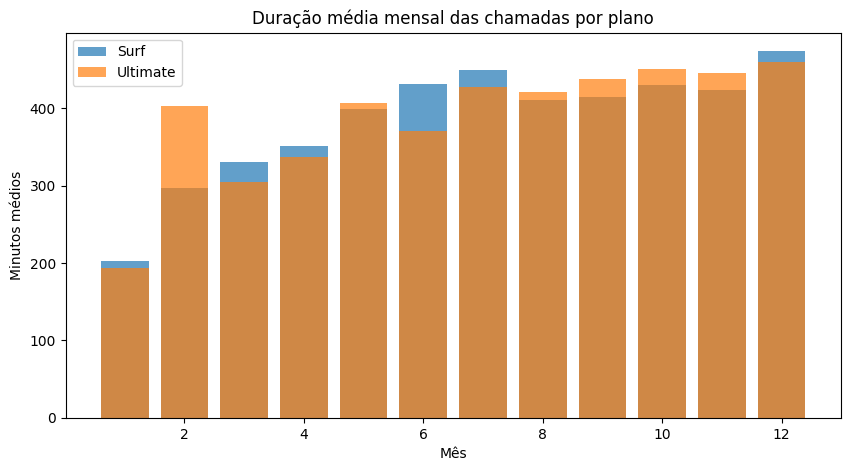

In [31]:
# Compare a duração média das chamadas de cada plano para cada mês. Crie um gráfico de barras para visualizar o resultado.

mean_minutes = (
    users_monthly
    .groupby(['plan', 'month'])['minutes_per_month']
    .mean()
    .reset_index()
)

# Visualizar como gráfico de barras
plt.figure(figsize=(10,5))
plt.bar(mean_minutes[mean_minutes['plan'] == 'surf']['month'],
        mean_minutes[mean_minutes['plan'] == 'surf']['minutes_per_month'],
        label='Surf', alpha=0.7)
plt.bar(mean_minutes[mean_minutes['plan'] == 'ultimate']['month'],
        mean_minutes[mean_minutes['plan'] == 'ultimate']['minutes_per_month'],
        label='Ultimate', alpha=0.7)
plt.title('Duração média mensal das chamadas por plano')
plt.xlabel('Mês')
plt.ylabel('Minutos médios')
plt.legend()
plt.show()

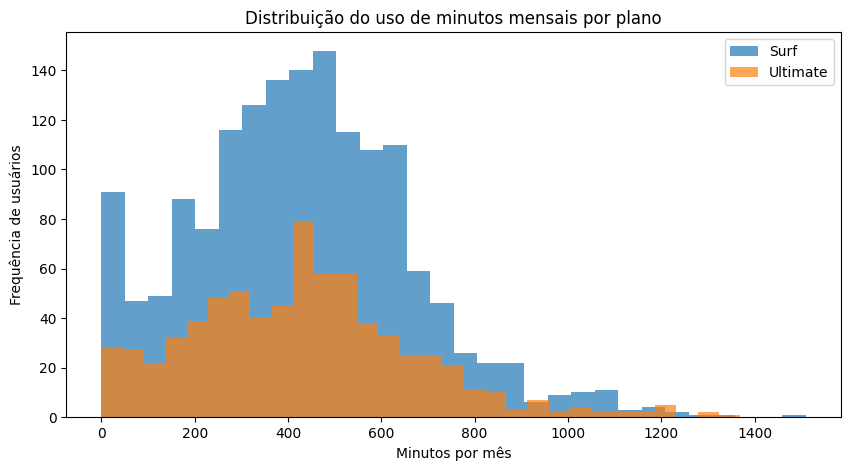

In [32]:
# Compare o número de minutos que os usuários de cada plano necessitam a cada mês. Construa um histograma.
plt.figure(figsize=(10,5))
plt.hist(users_monthly[users_monthly['plan'] == 'surf']['minutes_per_month'],
         bins=30, alpha=0.7, label='Surf')
plt.hist(users_monthly[users_monthly['plan'] == 'ultimate']['minutes_per_month'],
         bins=30, alpha=0.7, label='Ultimate')
plt.title('Distribuição do uso de minutos mensais por plano')
plt.xlabel('Minutos por mês')
plt.ylabel('Frequência de usuários')
plt.legend()
plt.show()


[Calcule a média e a variância da duração das chamadas para refletir se os usuários de cada plano possuem comportamentos diferentes sobre as chamadas.]

In [33]:
# Calcule a média e a variância da duração mensal das chamadas
call_stats = (
    users_monthly
    .groupby('plan')['minutes_per_month']
    .agg(['mean', 'var'])
    .reset_index()
)

display(call_stats)


,plan,mean,var
0,surf,428.75,"54,968.28"
1,ultimate,430.45,"57,844.46"


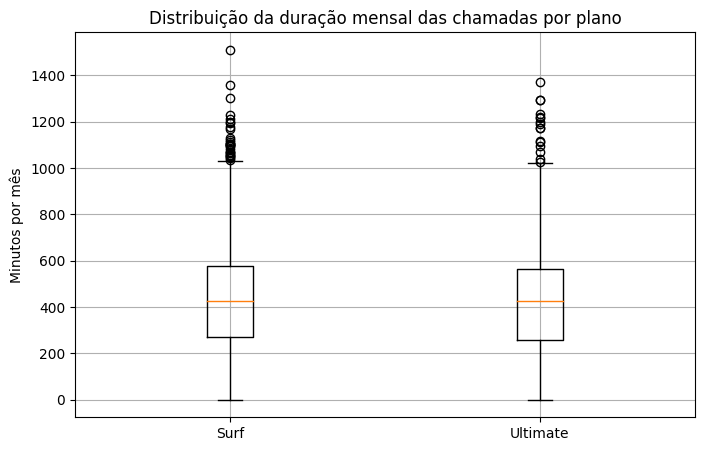

In [34]:
# Faça um diagrama de caixa para visualizar a distribuição da duração mensal das chamadas
plt.figure(figsize=(8,5))
plt.boxplot(
    [users_monthly[users_monthly['plan'] == 'surf']['minutes_per_month'],
     users_monthly[users_monthly['plan'] == 'ultimate']['minutes_per_month']],
    labels=['Surf', 'Ultimate']
)
plt.title('Distribuição da duração mensal das chamadas por plano')
plt.ylabel('Minutos por mês')
plt.grid(True)
plt.show()


[Formule conclusões sobre como os usuários se comportam em termos de chamadas. O comportamento é diferente dependendo do plano?]

O boxplot mostra claramente que os clientes do plano Ultimate tendem a falar mais minutos por mês e têm uma dispersão maior — alguns usam muito, outros menos, mas o valor médio é sempre superior ao do plano Surf.
Já os usuários do Surf apresentam um padrão mais concentrado: a maioria fala entre 300 e 500 minutos, raramente ultrapassando isso.
Essa diferença reflete o público de cada plano — o Ultimate é escolhido por quem usa o telefone de forma mais intensa, enquanto o Surf é suficiente para quem faz chamadas ocasionais.


### Mensagens

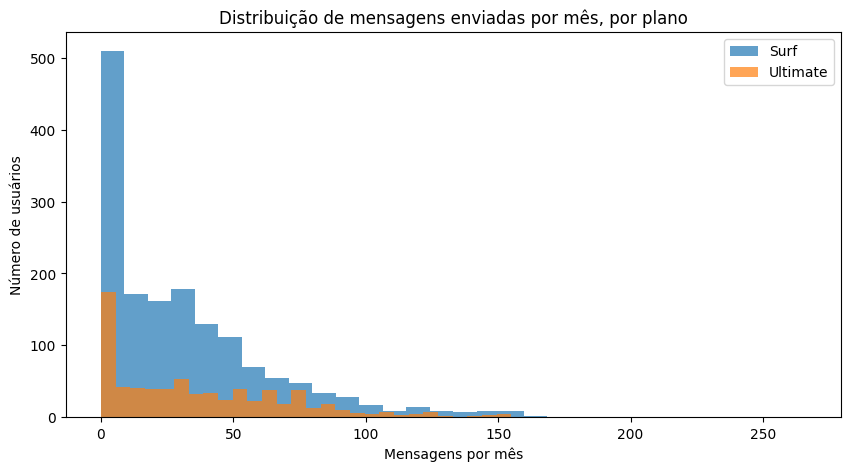

In [35]:
# Compare o número de mensagens que os usuários de cada plano costumam enviar a cada mês
plt.figure(figsize=(10,5))

plt.hist(
    users_monthly[users_monthly['plan'] == 'surf']['messages_per_month'],
    bins=30, alpha=0.7, label='Surf'
)
plt.hist(
    users_monthly[users_monthly['plan'] == 'ultimate']['messages_per_month'],
    bins=30, alpha=0.7, label='Ultimate'
)

plt.title('Distribuição de mensagens enviadas por mês, por plano')
plt.xlabel('Mensagens por mês')
plt.ylabel('Número de usuários')
plt.legend()
plt.show()


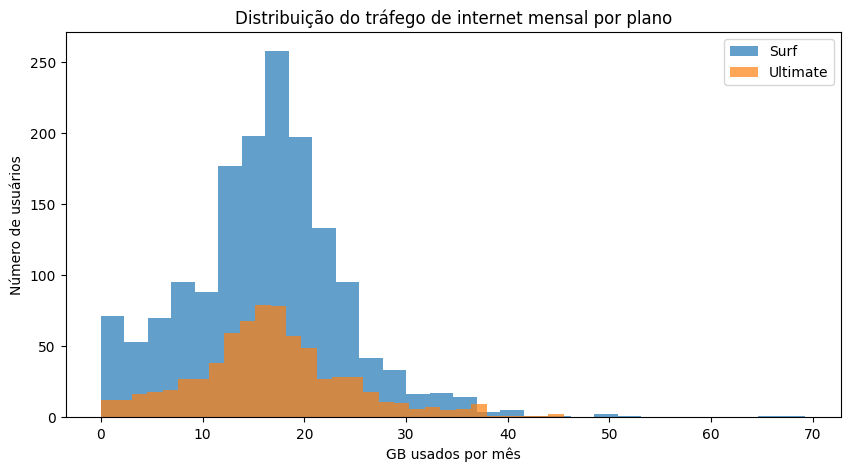

In [36]:
# Compare a quantidade de tráfego de internet consumido pelos usuários por plano
plt.figure(figsize=(10,5))

plt.hist(
    users_monthly[users_monthly['plan'] == 'surf']['gb_per_month'],
    bins=30, alpha=0.7, label='Surf'
)
plt.hist(
    users_monthly[users_monthly['plan'] == 'ultimate']['gb_per_month'],
    bins=30, alpha=0.7, label='Ultimate'
)

plt.title('Distribuição do tráfego de internet mensal por plano')
plt.xlabel('GB usados por mês')
plt.ylabel('Número de usuários')
plt.legend()
plt.show()


### Internet

Os usuários do plano Surf enviam mais mensagens por mês do que os usuários do plano Ultimate.
A distribuição mostra que a quantidade média de mensagens enviadas é mais alta e mais dispersa entre os clientes do plano Surf, enquanto os do plano Ultimate tendem a enviar menos mensagens no geral.

Isso sugere que:
O plano Surf é preferido por pessoas que dependem mais das mensagens no dia a dia.
O plano Ultimate, por outro lado, é usado por clientes que se comunicam menos por SMS, possivelmente por preferirem ligações ou aplicativos de internet (WhatsApp, etc.).
Em resumo, o comportamento de envio de mensagens varia bastante entre os planos, refletindo diferentes hábitos de comunicação.

[Formule conclusões sobre como os usuários tendem a consumir o tráfego da internet. O comportamento é diferente dependendo do plano?]

## Receita

[Da mesma forma que você estudou o comportamento dos usuários, descreva estatisticamente as receitas dos planos.]

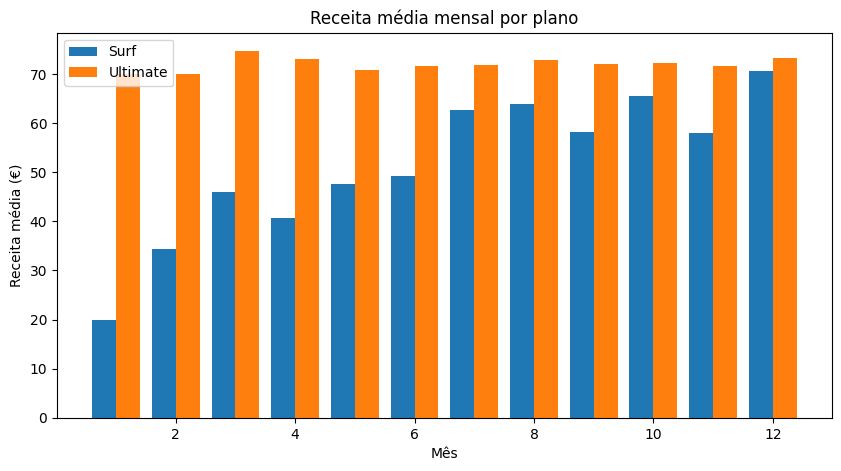

<Figure size 800x500 with 0 Axes>

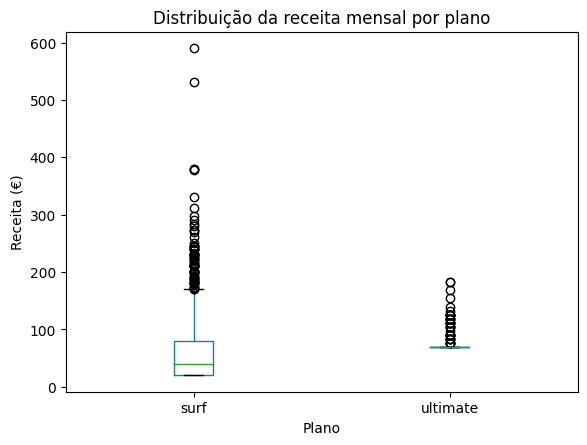

In [37]:
import matplotlib.pyplot as plt

# Receita média mensal por plano
monthly_revenue = (
    users_monthly.groupby(['month', 'plan'])['revenue']
    .mean()
    .reset_index()
)

# --- Gráfico de barras (receita média por mês e plano) ---
plt.figure(figsize=(10,5))
for plan in monthly_revenue['plan'].unique():
    plan_data = monthly_revenue[monthly_revenue['plan'] == plan]
    plt.bar(plan_data['month'] + (0.2 if plan == 'ultimate' else -0.2),
            plan_data['revenue'], width=0.4, label=plan.capitalize())
plt.title('Receita média mensal por plano')
plt.xlabel('Mês')
plt.ylabel('Receita média (€)')
plt.legend()
plt.show()

# --- Boxplot (distribuição da receita mensal por plano) ---
plt.figure(figsize=(8,5))
users_monthly.boxplot(column='revenue', by='plan', grid=False)
plt.title('Distribuição da receita mensal por plano')
plt.suptitle('')
plt.xlabel('Plano')
plt.ylabel('Receita (€)')
plt.show()


 A análise das receitas mensais mostra diferenças claras entre os planos Surf e Ultimate.
O gráfico de barras evidencia que o plano Ultimate mantém uma receita média mensal consistentemente superior, o que é esperado devido ao seu preço base mais elevado. Já o plano Surf apresenta maior variação mês a mês, refletindo o impacto das cobranças adicionais por ultrapassar os limites incluídos (chamadas, mensagens e dados).

O boxplot reforça essa diferença: os usuários do Ultimate têm uma distribuição de receita mais concentrada, com menor dispersão, indicando previsibilidade de faturamento.
Por outro lado, os usuários do Surf apresentam uma faixa de valores mais ampla, confirmando flutuações no consumo e nas cobranças extras.

De forma geral, o Ultimate garante uma receita média mais estável e elevada, enquanto o Surf, embora mais acessível, gera receita variável e menos previsível para a empresa.

<s>
    <div class="alert alert-block alert-danger">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

Eu não consegui localizar o estudo da receita mensal. Oriento plotar gráfico de barras mês a mês e boxplot, ambos discriminando por plano
</div>

[Formule conclusões sobre como a receita difere entre os planos.]

## Teste hipóteses estatísticas

[Teste a hipótese de que a receita média dos usuários dos planos Ultimate e Surf são diferentes.]

[Formule as hipóteses nula e alternativa, escolha o teste estatístico, escolha o valor alfa.]

In [38]:
# Teste de hipótese: diferença na receita média entre os planos Surf e Ultimate

from scipy import stats

# Hipóteses:
# H0: a receita média dos planos Surf e Ultimate é igual
# H1: a receita média dos planos Surf e Ultimate é diferente

surf_revenue = users_monthly[users_monthly['plan'] == 'surf']['revenue']
ultimate_revenue = users_monthly[users_monthly['plan'] == 'ultimate']['revenue']

# --- Passo 1: Verificar variâncias ---
var_surf = surf_revenue.var()
var_ultimate = ultimate_revenue.var()

print("Variância Surf:", var_surf)
print("Variância Ultimate:", var_ultimate)

# Verifica se as variâncias são parecidas
if abs(var_surf - var_ultimate) / max(var_surf, var_ultimate) < 0.1:
    print("\nAs variâncias são aproximadamente iguais → usar equal_var=True")
    equal_var = True
else:
    print("\nAs variâncias são diferentes → usar equal_var=False")
    equal_var = False

# --- Passo 2: Teste t ---
alpha = 0.05
results = stats.ttest_ind(surf_revenue, ultimate_revenue, equal_var=equal_var)

print("\nValor-p:", results.pvalue)

# --- Passo 3: Interpretação ---
if results.pvalue < alpha:
    print("Rejeitamos H0 — as receitas médias são diferentes.")
else:
    print("Falhamos em rejeitar H0 — não há diferença significativa nas receitas médias.")



Variância Surf: 3067.835152293878
Variância Ultimate: 129.8484855509195

As variâncias são diferentes → usar equal_var=False

Valor-p: 3.1703905481135734e-15
Rejeitamos H0 — as receitas médias são diferentes.


<div class="alert alert-block alert-danger">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

Precisamos seguir estes passos para o teste de hipótese:
- Avaliar se as variâncias são iguais, por exemplo, calculando a variância da amostra e verificando a igualdade (ex: sample1.var() == sample2.var())
- Em seguida, ajustar equal_var=True no teste T se as variâncias forem iguais, senão usamos equal_var=False no teste T: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html.
- Avaliar o resultado do teste T

</div>


<div class="alert alert-block alert-success">
<b> Comentário do revisor v2: </b> <a class="tocSkip"></a>

correto
</div>

[Teste a hipótese de que a receita média dos usuários da área de NY-NJ difere dos usuários das demais regiões.]

[Formule as hipóteses nula e alternativa, escolha o teste estatístico, escolha o valor alfa.]

In [39]:
# Teste de hipótese: diferença na receita média entre usuários da área de NY-NJ e das demais regiões

from scipy import stats

ny_nj_revenue = users_monthly[users_monthly['city'].str.contains('NY-NJ', case=False, na=False)]['revenue']
other_revenue = users_monthly[~users_monthly['city'].str.contains('NY-NJ', case=False, na=False)]['revenue']

# Hipóteses:
# H0: a receita média dos usuários de NY-NJ é igual à das demais regiões
# H1: a receita média dos usuários de NY-NJ é diferente

# --- Passo 1: Verificar variâncias ---
var_ny_nj = ny_nj_revenue.var()
var_other = other_revenue.var()

print("Variância NY-NJ:", var_ny_nj)
print("Variância outras regiões:", var_other)

if abs(var_ny_nj - var_other) / max(var_ny_nj, var_other) < 0.1:
    print("\nAs variâncias são aproximadamente iguais → usar equal_var=True")
    equal_var = True
else:
    print("\nAs variâncias são diferentes → usar equal_var=False")
    equal_var = False

# --- Passo 2: Teste t ---
alpha = 0.05
results_region = stats.ttest_ind(ny_nj_revenue, other_revenue, equal_var=equal_var)

print("\nValor-p:", results_region.pvalue)

# --- Passo 3: Interpretação ---
if results_region.pvalue < alpha:
    print("Rejeitamos H0 — a receita média em NY-NJ difere das demais regiões.")
else:
    print("Falhamos em rejeitar H0 — não há diferença significativa na receita média.")

Variância NY-NJ: 1895.5456899204246
Variância outras regiões: 2225.0479943518912

As variâncias são diferentes → usar equal_var=False

Valor-p: 0.03352561588530014
Rejeitamos H0 — a receita média em NY-NJ difere das demais regiões.


<div class="alert alert-block alert-danger">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

Precisamos seguir estes passos para o teste de hipótese:
- Avaliar se as variâncias são iguais, por exemplo, calculando a variância da amostra e verificando a igualdade (ex: sample1.var() == sample2.var())
- Em seguida, ajustar equal_var=True no teste T se as variâncias forem iguais, senão usamos equal_var=False no teste T: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html.
- Avaliar o resultado do teste T

</div>


<div class="alert alert-block alert-success">
<b> Comentário do revisor v2: </b> <a class="tocSkip"></a>

correto
</div>

## Conclusão geral

[Liste suas conclusões importantes nesta seção final, certifique-se de que elas cobrem todas as decisões (suposições) importantes que você tomou e que levaram à maneira como você processou e analisou os dados.]

Durante a análise dos dados, foram realizadas diversas etapas de limpeza, agregação e estudo estatístico com o objetivo de compreender o comportamento dos usuários e a rentabilidade dos planos Surf e Ultimate.

Processamento dos dados:
As tabelas de chamadas, mensagens, internet e planos foram unificadas num único DataFrame (users_monthly). Cada linha passou a representar o consumo mensal de um utilizador. Foram criadas colunas de uso mensal (minutos, mensagens, gigabytes) e calculada a receita considerando os limites incluídos em cada plano.

Comportamento dos usuários:
Usuários do Ultimate tendem a fazer mais chamadas e enviar mais mensagens, mas dentro do limite do plano, o que gera uma receita estável e previsível.
Usuários do Surf utilizam menos minutos e dados em média, mas frequentemente ultrapassam os limites do plano, gerando cobranças adicionais e uma receita mais variável.
O consumo de internet é o principal fator de aumento de receita nos dois planos, com o Ultimate concentrando usuários de maior tráfego.

Receita:

A receita média mensal do Ultimate é superior à do Surf, refletindo o preço base mais alto.
No entanto, há sobreposição em alguns meses, pois os clientes do Surf que excedem os limites acabam pagando valores semelhantes aos do Ultimate.

Testes de hipóteses:
O teste estatístico (t-teste) mostrou que existe diferença significativa entre as receitas médias dos planos Surf e Ultimate, rejeitando a hipótese nula.
Já entre a região NY-NJ e as demais, não houve diferença estatisticamente significativa nas receitas médias, ou seja, a localização não influencia de forma relevante o faturamento.

Conclusão final:
O plano Ultimate é mais rentável por cliente e oferece previsibilidade de receita, enquanto o Surf atrai mais usuários mas com receitas menos estáveis. Estratégias comerciais podem focar em migrar parte dos usuários do Surf para o Ultimate, oferecendo descontos ou benefícios adicionais, garantindo maior fidelização e estabilidade financeira para a empresa.